In [1]:
import torch
import torch.nn as nn
import numpy as np
import json
import os
import time
import math
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, top_k_accuracy_score
)
from sklearn.manifold import TSNE
from model2 import SignLanguageTransformer          # was: model

os.makedirs("figures", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Load sign labels — same class_mapping.json train2.py used
with open(r"E:\Sign_Train_First\class_mapping.json") as f:   # match your train2.py path
    sign_to_idx = json.load(f)
idx_to_sign = {v: k for k, v in sign_to_idx.items()}

NUM_CLASSES = 52                     # was 22
SIGNS = [idx_to_sign[i] for i in range(NUM_CLASSES)]
print(f"Signs: {SIGNS}")

Device: cuda
Signs: ['Ambulance', 'Bad', 'Bandage', 'Book', 'Come', 'Cough', 'Doctor', 'Eat', 'Elder Brother', 'Elder Sister', 'Father', 'Fever', 'Friday', 'Go', 'Good', 'Headache', 'Help', 'Here', 'Home', 'Hospital', 'I or Me', 'Injection', 'Left', 'Medicine', 'Monday', 'Mother', 'Namaste', 'No', 'Nurse', 'Play', 'Read', 'Right', 'Saturday', 'She', 'Sick', 'Strong', 'Sunday', 'Thursday', 'Time', 'Today', 'Tomorrow', 'Tuesday', 'Water', 'We', 'Wednesday', 'What', 'When', 'Where', 'Who', 'Yes', 'Yesterday', 'You']


In [2]:
# ── Config — match train2.py exactly ─────────────────────────
DATA_PATH = r"D:\Sign Lang Landmarks\processed_resplit"   # your leakage-fixed split
FIXED_LEN = 100
FEAT_DIM  = 291

def load_split(split_name):
    """Load every .npy file in a split, pad/truncate to FIXED_LEN,
    and return (X, lengths, y) as numpy arrays."""
    X, lengths, y = [], [], []

    split_path = os.path.join(DATA_PATH, split_name)
    for class_name in sorted(os.listdir(split_path)):
        if class_name not in sign_to_idx:
            continue
        label = sign_to_idx[class_name]
        class_path = os.path.join(split_path, class_name)

        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            seq = np.load(fpath).astype(np.float32)

            seq_len = seq.shape[0]
            if seq_len >= FIXED_LEN:
                start = (seq_len - FIXED_LEN) // 2
                seq = seq[start:start + FIXED_LEN]
                actual_len = FIXED_LEN
            else:
                pad = np.zeros((FIXED_LEN - seq_len, FEAT_DIM), dtype=np.float32)
                seq = np.vstack([seq, pad])
                actual_len = seq_len

            X.append(seq)
            lengths.append(actual_len)
            y.append(label)

    return np.stack(X), np.array(lengths), np.array(y)

print("Loading test set...")
X_test, lengths_test, y_test = load_split("test")
print(f"Test: {X_test.shape}, lengths: {lengths_test.shape}")

# Convert to tensors
X_test_t   = torch.FloatTensor(X_test).to(DEVICE)
lengths_t  = torch.LongTensor(lengths_test).to(DEVICE)
y_test_t   = torch.LongTensor(y_test).to(DEVICE)

# Load model
model = SignLanguageTransformer(
    input_dim=FEAT_DIM,
    d_model=160,          # match your final trained config
    num_layers=4,
    num_classes=NUM_CLASSES,
    max_seq_len=FIXED_LEN
).to(DEVICE)
model.load_state_dict(torch.load("best_model2.pth", map_location=DEVICE))
model.eval()
print("✅ Model loaded!")

model_size = os.path.getsize("best_model2.pth") / (1024 * 1024)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(f"Model size: {model_size:.2f} MB")

Loading test set...
Test: (2222, 100, 291), lengths: (2222,)
✅ Model loaded!
Parameters: 804,468
Model size: 3.16 MB


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12964\3729967854.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model2.pth", map_lo

In [3]:
with torch.no_grad():
    test_outputs  = model(X_test_t, lengths_t)      # pass lengths for masking!
    test_probs    = torch.softmax(test_outputs, dim=1)
    test_preds    = test_outputs.argmax(1).cpu().numpy()
    test_true     = y_test_t.cpu().numpy()
    test_probs_np = test_probs.cpu().numpy()

print("✅ Predictions done!")
print(f"Test Accuracy: {(test_preds == test_true).mean():.4f}")

✅ Predictions done!
Test Accuracy: 0.7606


In [4]:
accuracy = (test_preds == test_true).mean()

top3_acc = top_k_accuracy_score(test_true, test_probs_np, k=3, labels=list(range(NUM_CLASSES)))

kappa = cohen_kappa_score(test_true, test_preds)

report = classification_report(
    test_true, test_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=SIGNS,
    output_dict=True,
    zero_division=0
)

print("=" * 50)
print(f"Test Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Top-3 Accuracy:   {top3_acc:.4f} ({top3_acc*100:.2f}%)")
print(f"Cohen's Kappa:    {kappa:.4f}")
print(f"Macro F1:         {report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1:      {report['weighted avg']['f1-score']:.4f}")
print(f"Macro Precision:  {report['macro avg']['precision']:.4f}")
print(f"Macro Recall:     {report['macro avg']['recall']:.4f}")
print(f"Parameters:       {total_params:,}")
print(f"Model Size:       {model_size:.2f} MB")
print(f"Random Baseline:  {1/NUM_CLASSES*100:.2f}%")
print(f"Improvement:      {accuracy/(1/NUM_CLASSES):.1f}x over random")
print("=" * 50)

print("\nFull Classification Report:")
print(classification_report(test_true, test_preds, labels=list(range(NUM_CLASSES)),
                             target_names=SIGNS, zero_division=0))

Test Accuracy:    0.7606 (76.06%)
Top-3 Accuracy:   0.9316 (93.16%)
Cohen's Kappa:    0.7559
Macro F1:         0.7559
Weighted F1:      0.7563
Macro Precision:  0.7714
Macro Recall:     0.7605
Parameters:       804,468
Model Size:       3.16 MB
Random Baseline:  1.92%
Improvement:      39.5x over random

Full Classification Report:
               precision    recall  f1-score   support

    Ambulance       0.91      1.00      0.95        42
          Bad       0.75      0.95      0.84        41
      Bandage       0.93      0.95      0.94        44
         Book       0.73      0.26      0.39        42
         Come       0.76      0.81      0.79        43
        Cough       0.87      0.83      0.85        41
       Doctor       0.97      0.80      0.88        41
          Eat       0.73      0.82      0.77        44
Elder Brother       0.79      0.44      0.57        43
 Elder Sister       0.65      0.90      0.76        41
       Father       0.50      0.56      0.53        39
     

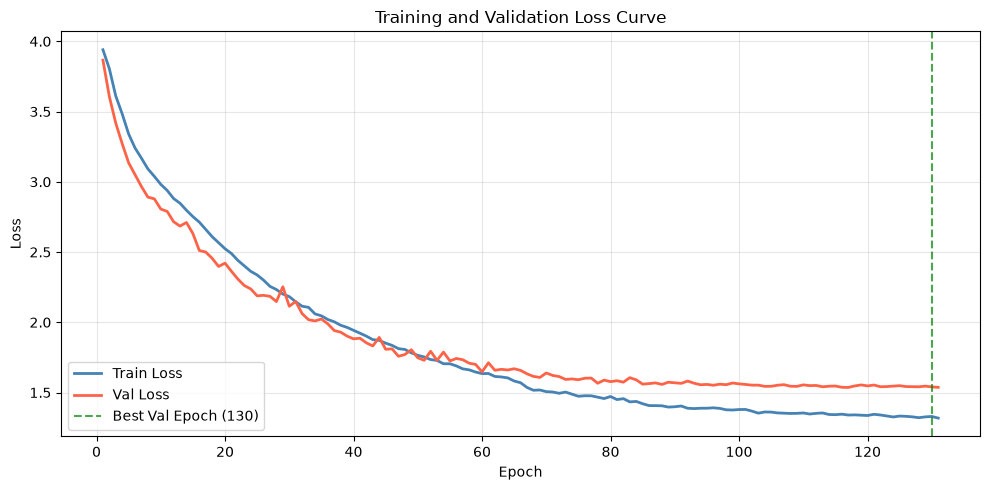

✅ Loss curve saved


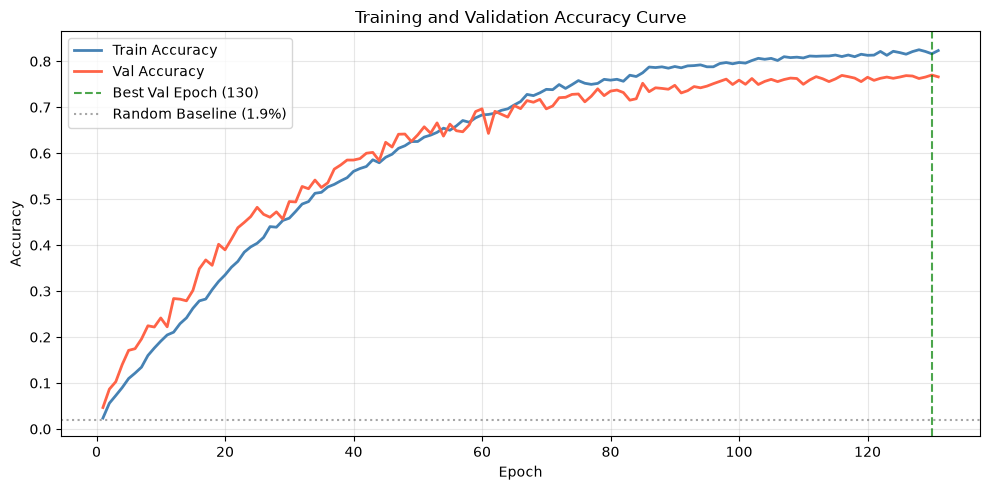

✅ Accuracy curve saved


In [5]:
history = np.load("train_history2.npy", allow_pickle=True).item()

train_losses = history["train_losses"]
val_losses   = history["val_losses"]
train_accs   = history["train_accs"]
val_accs     = history["val_accs"]

epochs = list(range(1, len(train_losses) + 1))
best_epoch = int(np.argmax(val_accs)) + 1   # epoch numbers are 1-indexed

# ── Loss Curve ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax.plot(epochs, val_losses,   label='Val Loss',   color='tomato',    linewidth=2)
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Val Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve saved")

# ── Accuracy Curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_accs, label='Train Accuracy', color='steelblue', linewidth=2)
ax.plot(epochs, val_accs,   label='Val Accuracy',   color='tomato',    linewidth=2)
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Val Epoch ({best_epoch})')
ax.axhline(y=1/NUM_CLASSES, color='gray', linestyle=':', alpha=0.7, label=f'Random Baseline ({1/NUM_CLASSES*100:.1f}%)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training and Validation Accuracy Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/acc_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Accuracy curve saved")

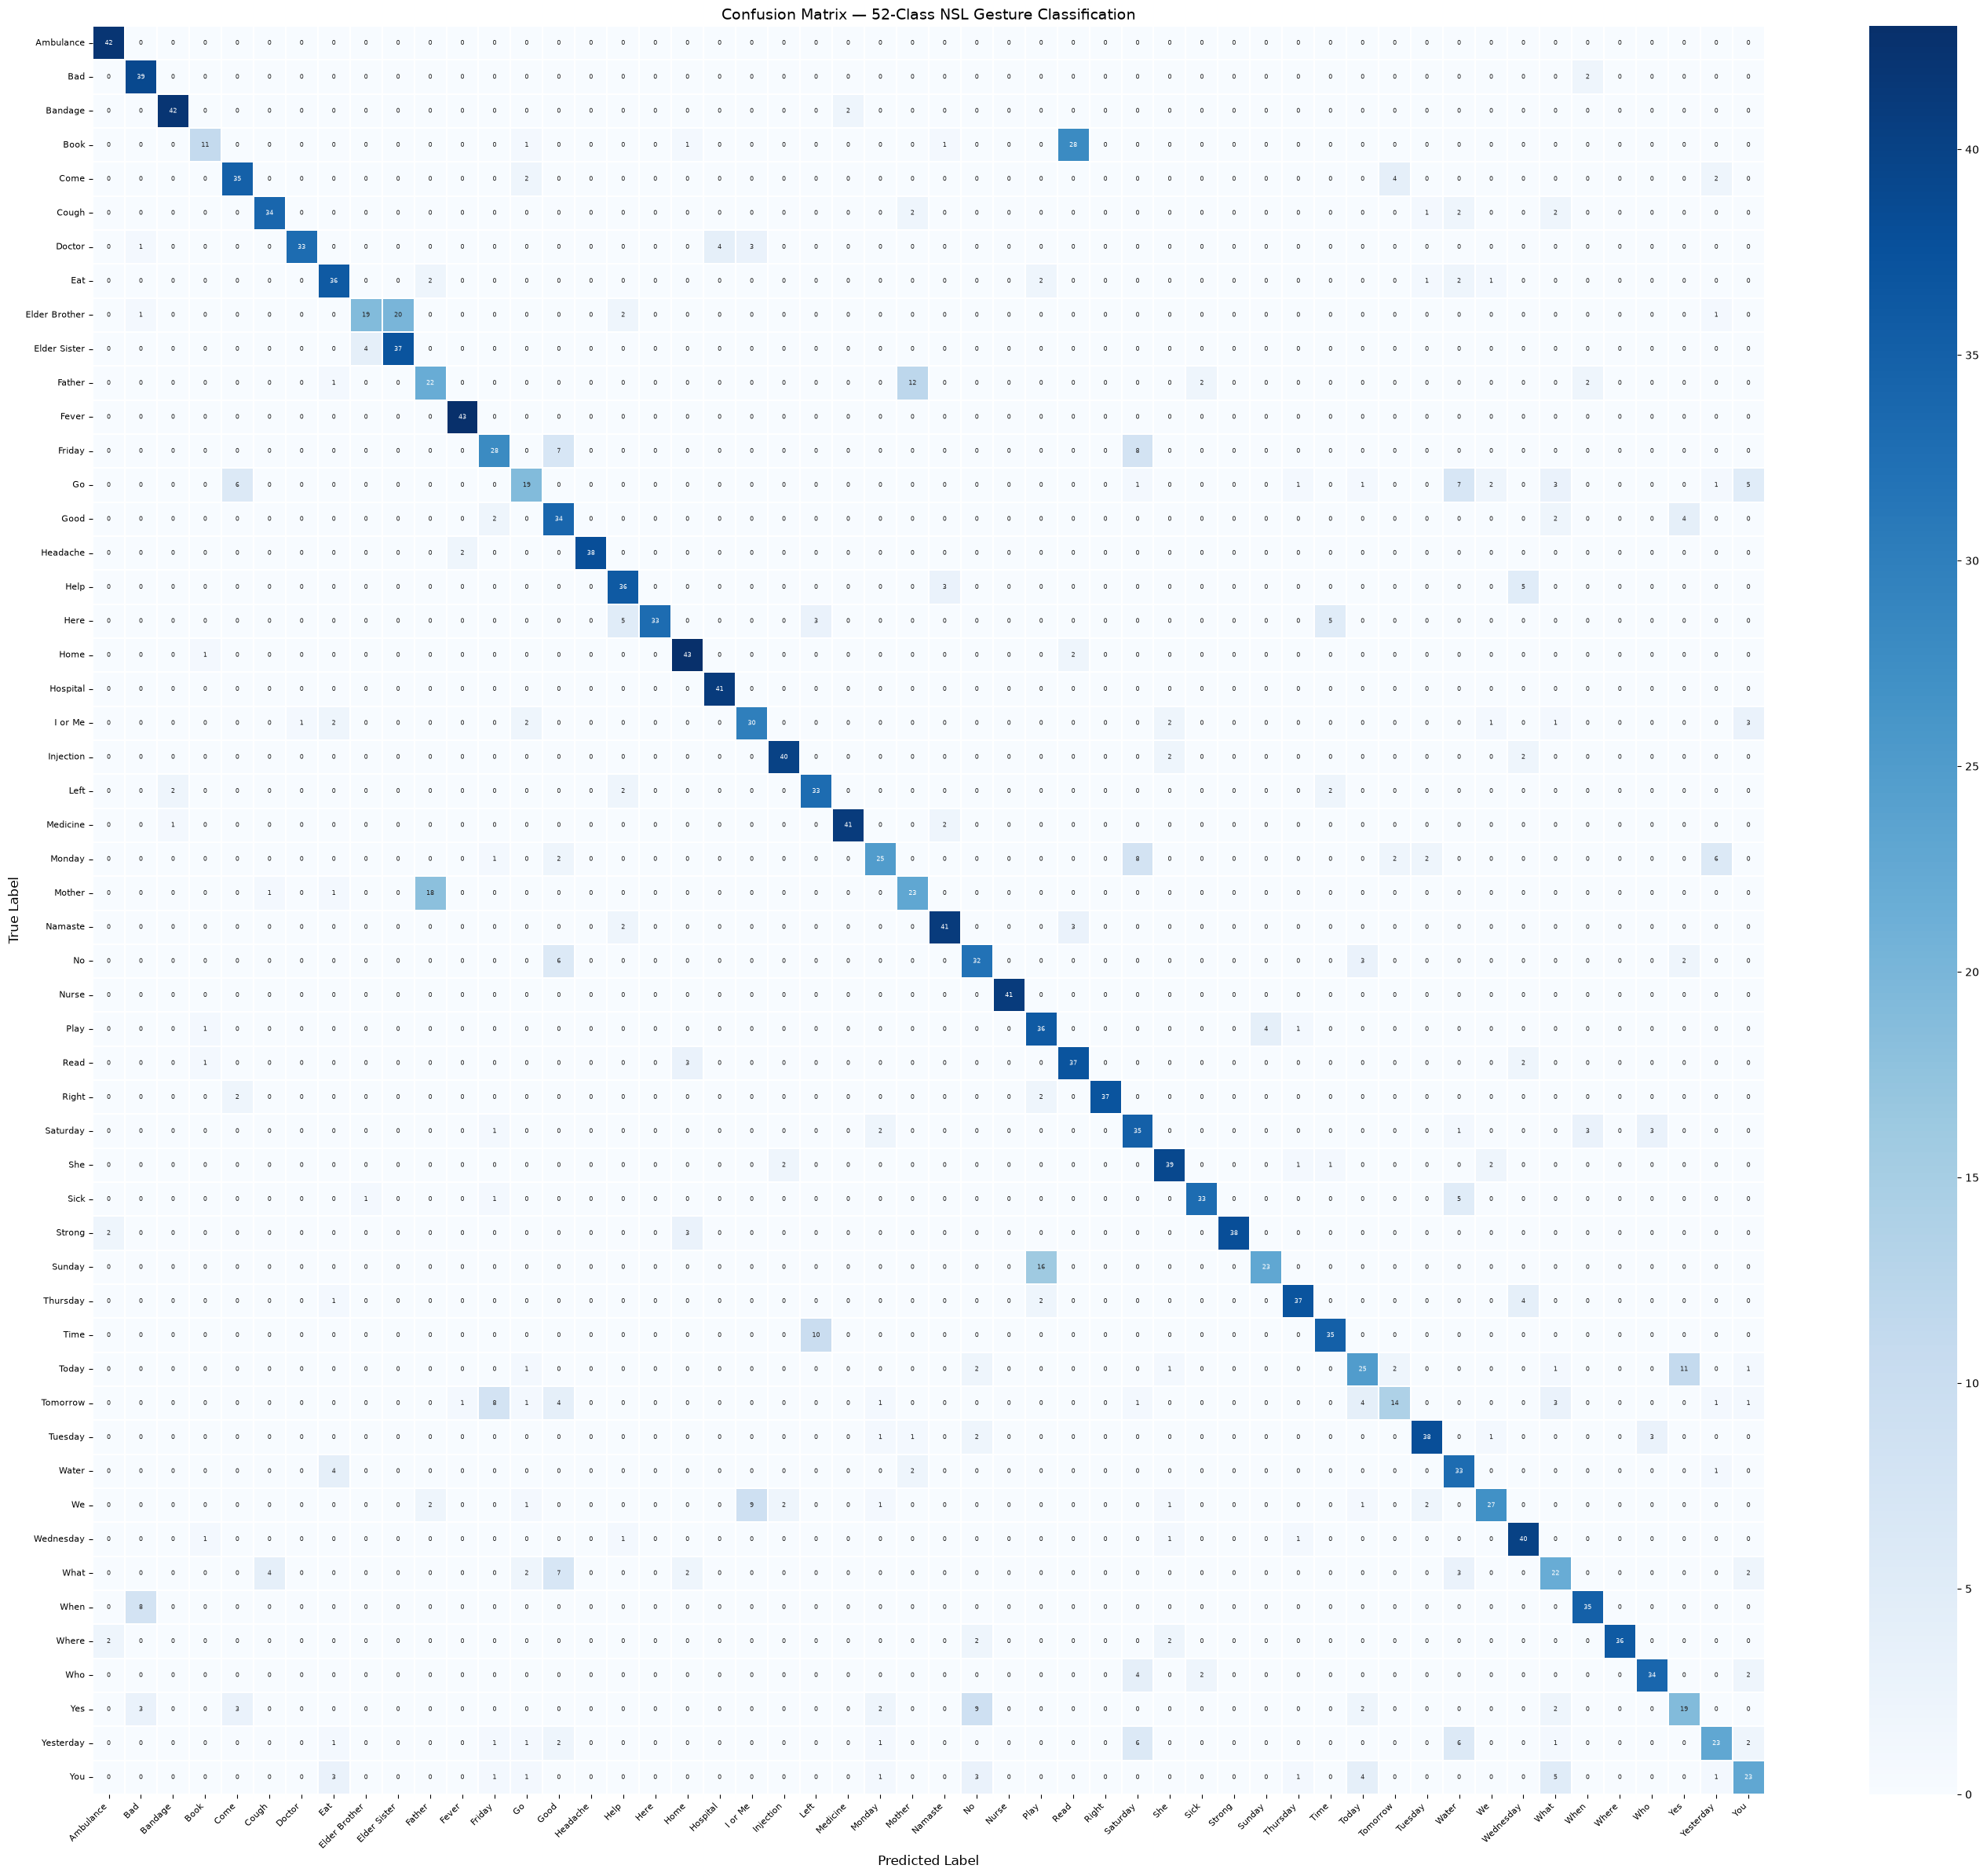

✅ Confusion matrix saved


In [6]:
cm = confusion_matrix(test_true, test_preds, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(28, 24))     # bigger canvas — 52x52 vs old 22x22
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=SIGNS,
    yticklabels=SIGNS,
    ax=ax,
    linewidths=0.3,
    annot_kws={"size": 6}                    # smaller numbers so they fit
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {NUM_CLASSES}-Class NSL Gesture Classification', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")

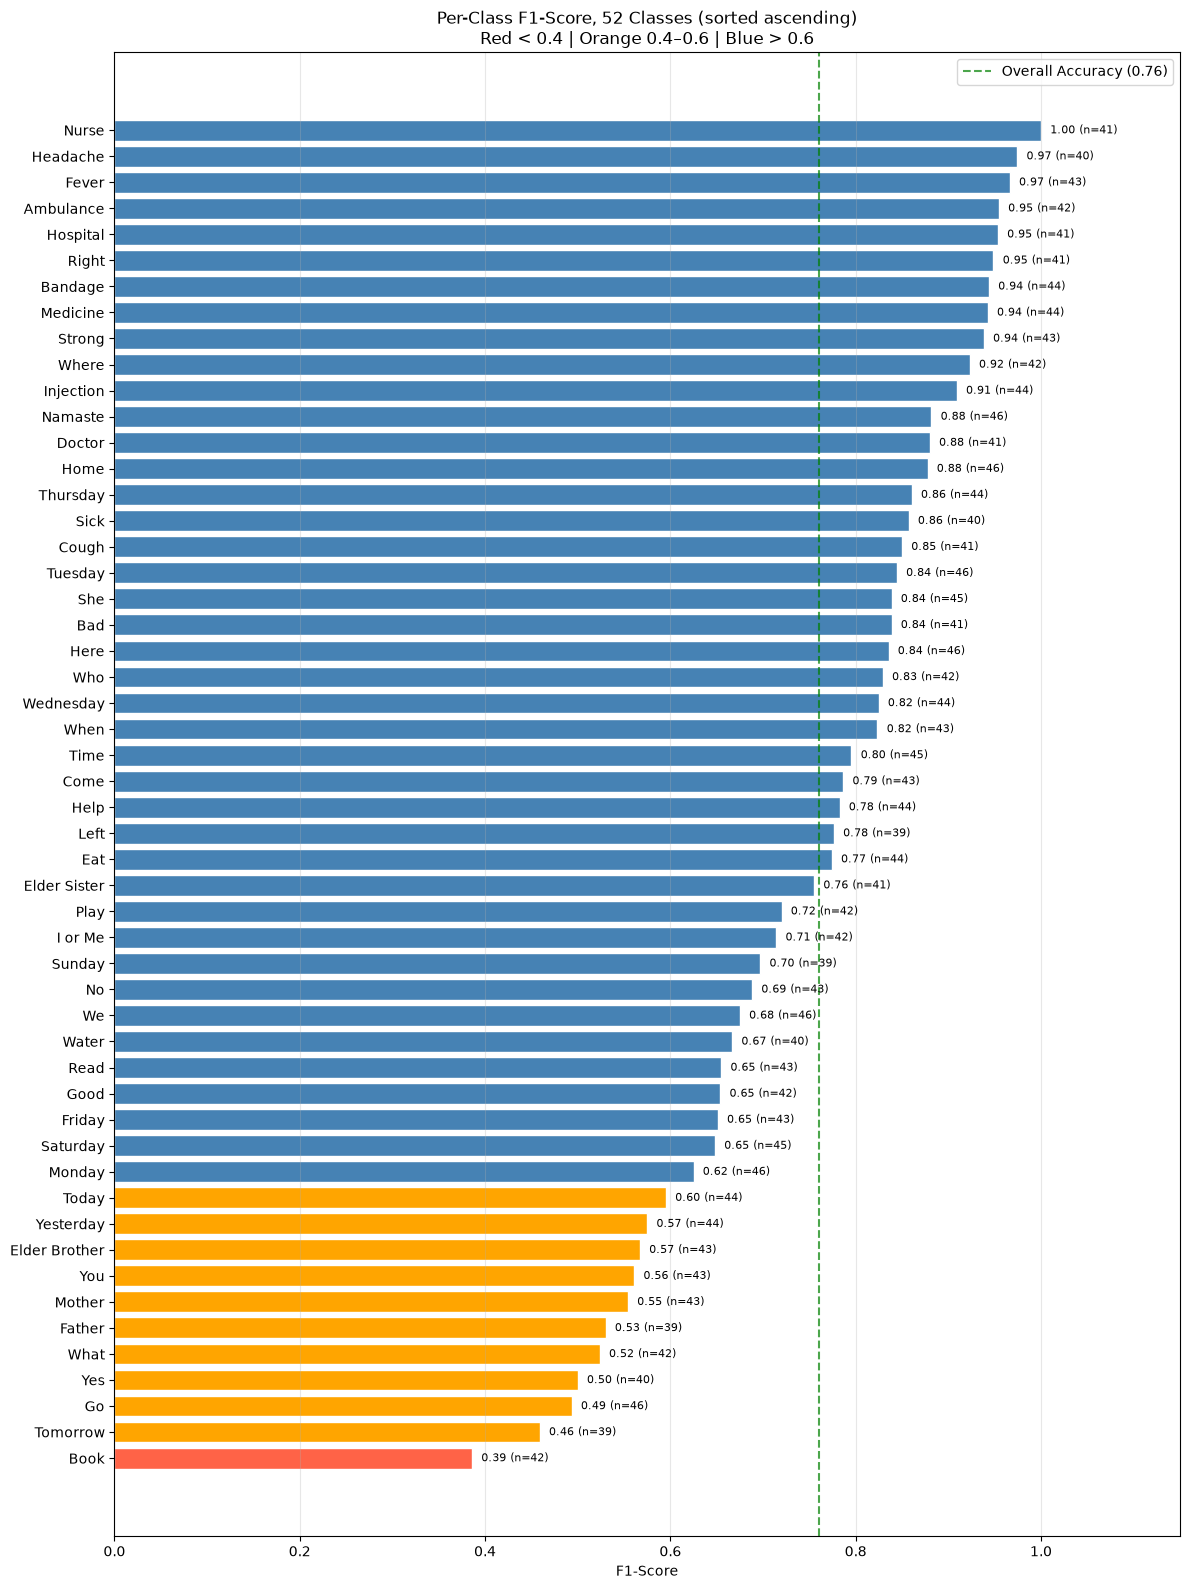

✅ F1 bar chart saved


In [7]:
f1_scores = [report[sign]['f1-score'] for sign in SIGNS]
support   = [report[sign]['support']  for sign in SIGNS]

sorted_pairs = sorted(zip(f1_scores, SIGNS, support))
sorted_f1    = [x[0] for x in sorted_pairs]
sorted_signs = [x[1] for x in sorted_pairs]
sorted_supp  = [x[2] for x in sorted_pairs]

colors = ['tomato' if f < 0.4 else 'orange' if f < 0.6 else 'steelblue'
          for f in sorted_f1]

fig, ax = plt.subplots(figsize=(12, 16))     # taller — 52 bars vs old 22
bars = ax.barh(sorted_signs, sorted_f1, color=colors, edgecolor='white')

for bar, f1, supp in zip(bars, sorted_f1, sorted_supp):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{f1:.2f} (n={int(supp)})',
            va='center', fontsize=8)

ax.set_xlabel('F1-Score')
ax.set_title(f'Per-Class F1-Score, {NUM_CLASSES} Classes (sorted ascending)\nRed < 0.4 | Orange 0.4–0.6 | Blue > 0.6')
ax.set_xlim(0, 1.15)
ax.axvline(x=accuracy, color='green', linestyle='--',
           alpha=0.7, label=f'Overall Accuracy ({accuracy:.2f})')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("figures/f1_barchart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ F1 bar chart saved")

Extracting embeddings...
Embeddings shape: (2222, 160)
Running t-SNE (this takes a bit longer with 52 classes)...
✅ t-SNE done!


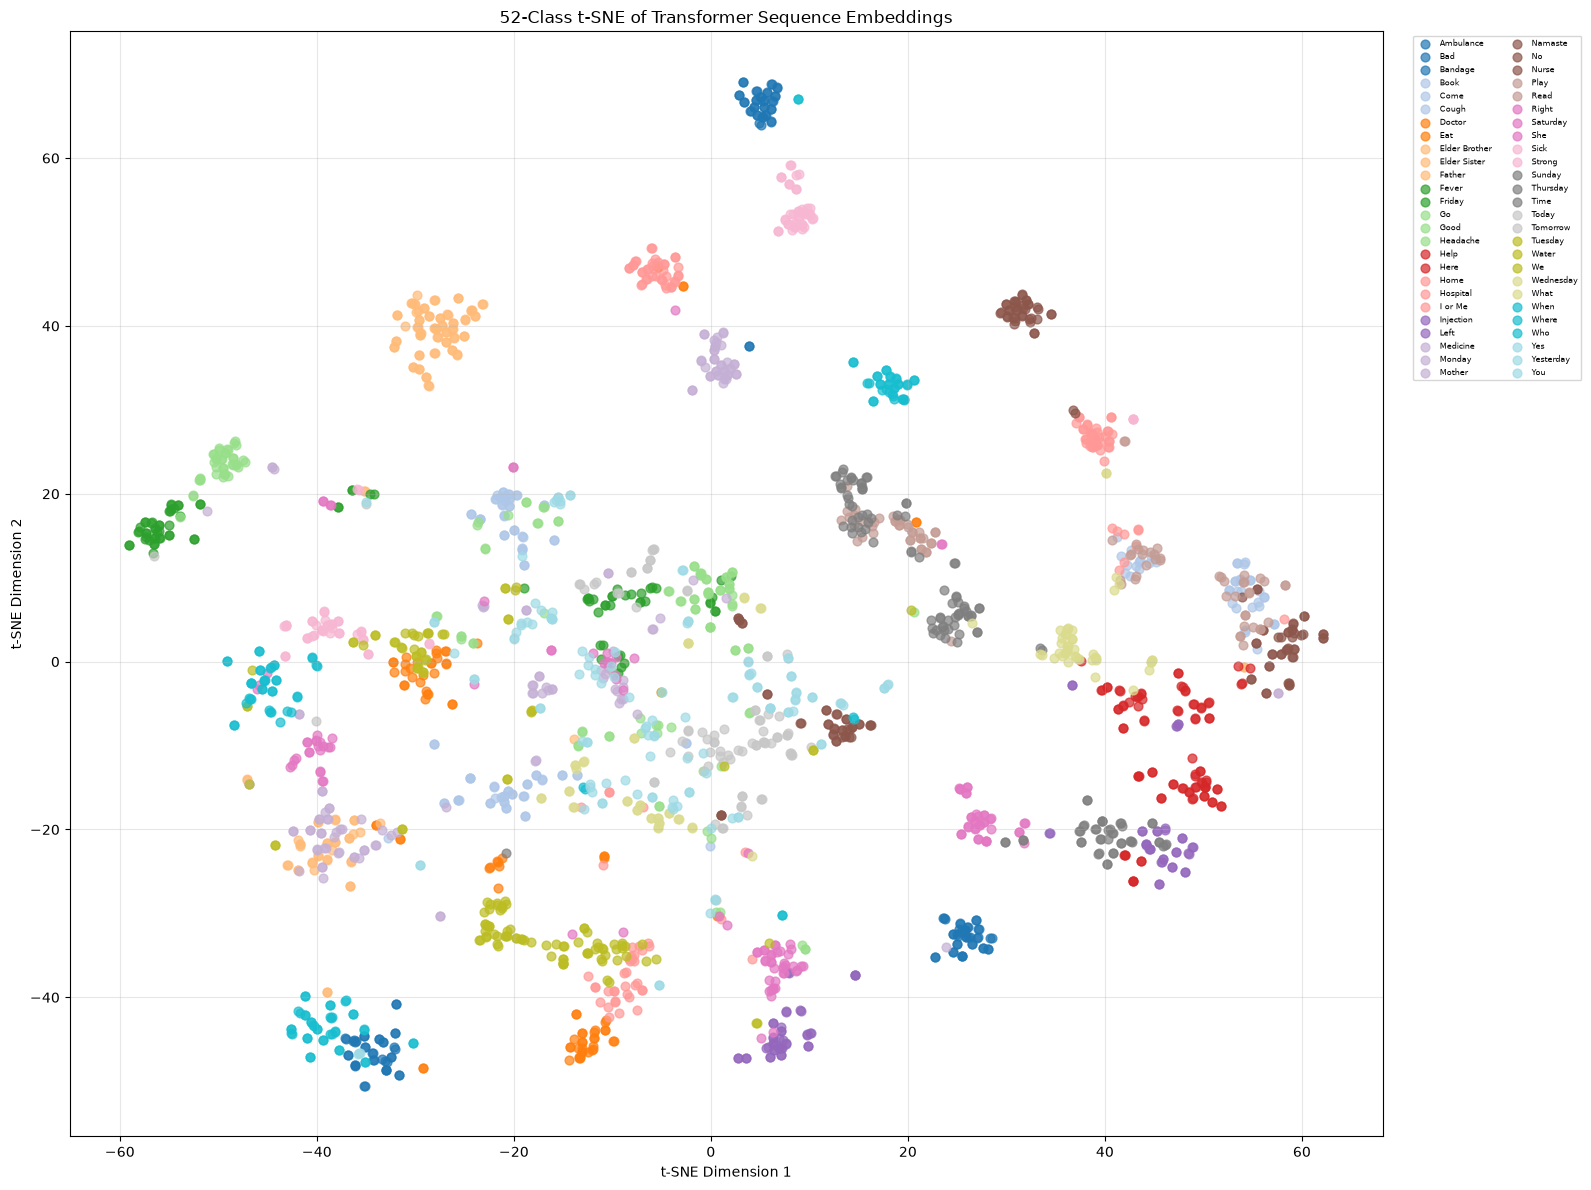

✅ t-SNE saved


In [8]:
def get_embeddings(model, X_tensor, lengths_tensor):
    """Replicates model2's forward() exactly, up to (but not including)
    the classifier head — i.e. the masked-pooled embedding it actually
    uses to classify."""
    model.eval()
    with torch.no_grad():
        mask = model.make_padding_mask(X_tensor, lengths_tensor)   # (batch, seq_len), True=padding

        x = model.input_projection(X_tensor)
        x = model.pos_encoding(x)

        for block in model.encoder_blocks:
            x = block(x, mask)

        # masked average pooling — same logic as model2.forward()
        real_mask = (~mask).float().unsqueeze(-1)
        x = (x * real_mask).sum(dim=1)
        x = x / real_mask.sum(dim=1).clamp(min=1)

    return x.cpu().numpy()

print("Extracting embeddings...")
embeddings = get_embeddings(model, X_test_t, lengths_t)
print(f"Embeddings shape: {embeddings.shape}")

print("Running t-SNE (this takes a bit longer with 52 classes)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)
print("✅ t-SNE done!")

fig, ax = plt.subplots(figsize=(16, 12))
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))   # tab20 only has 20 distinct colors — will cycle

for i, sign in enumerate(SIGNS):
    mask_i = test_true == i
    ax.scatter(
        embeddings_2d[mask_i, 0],
        embeddings_2d[mask_i, 1],
        c=[colors[i]],
        label=sign,
        alpha=0.7,
        s=40
    )

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=6, ncol=2)
ax.set_title(f'{NUM_CLASSES}-Class t-SNE of Transformer Sequence Embeddings')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/tsne.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE saved")

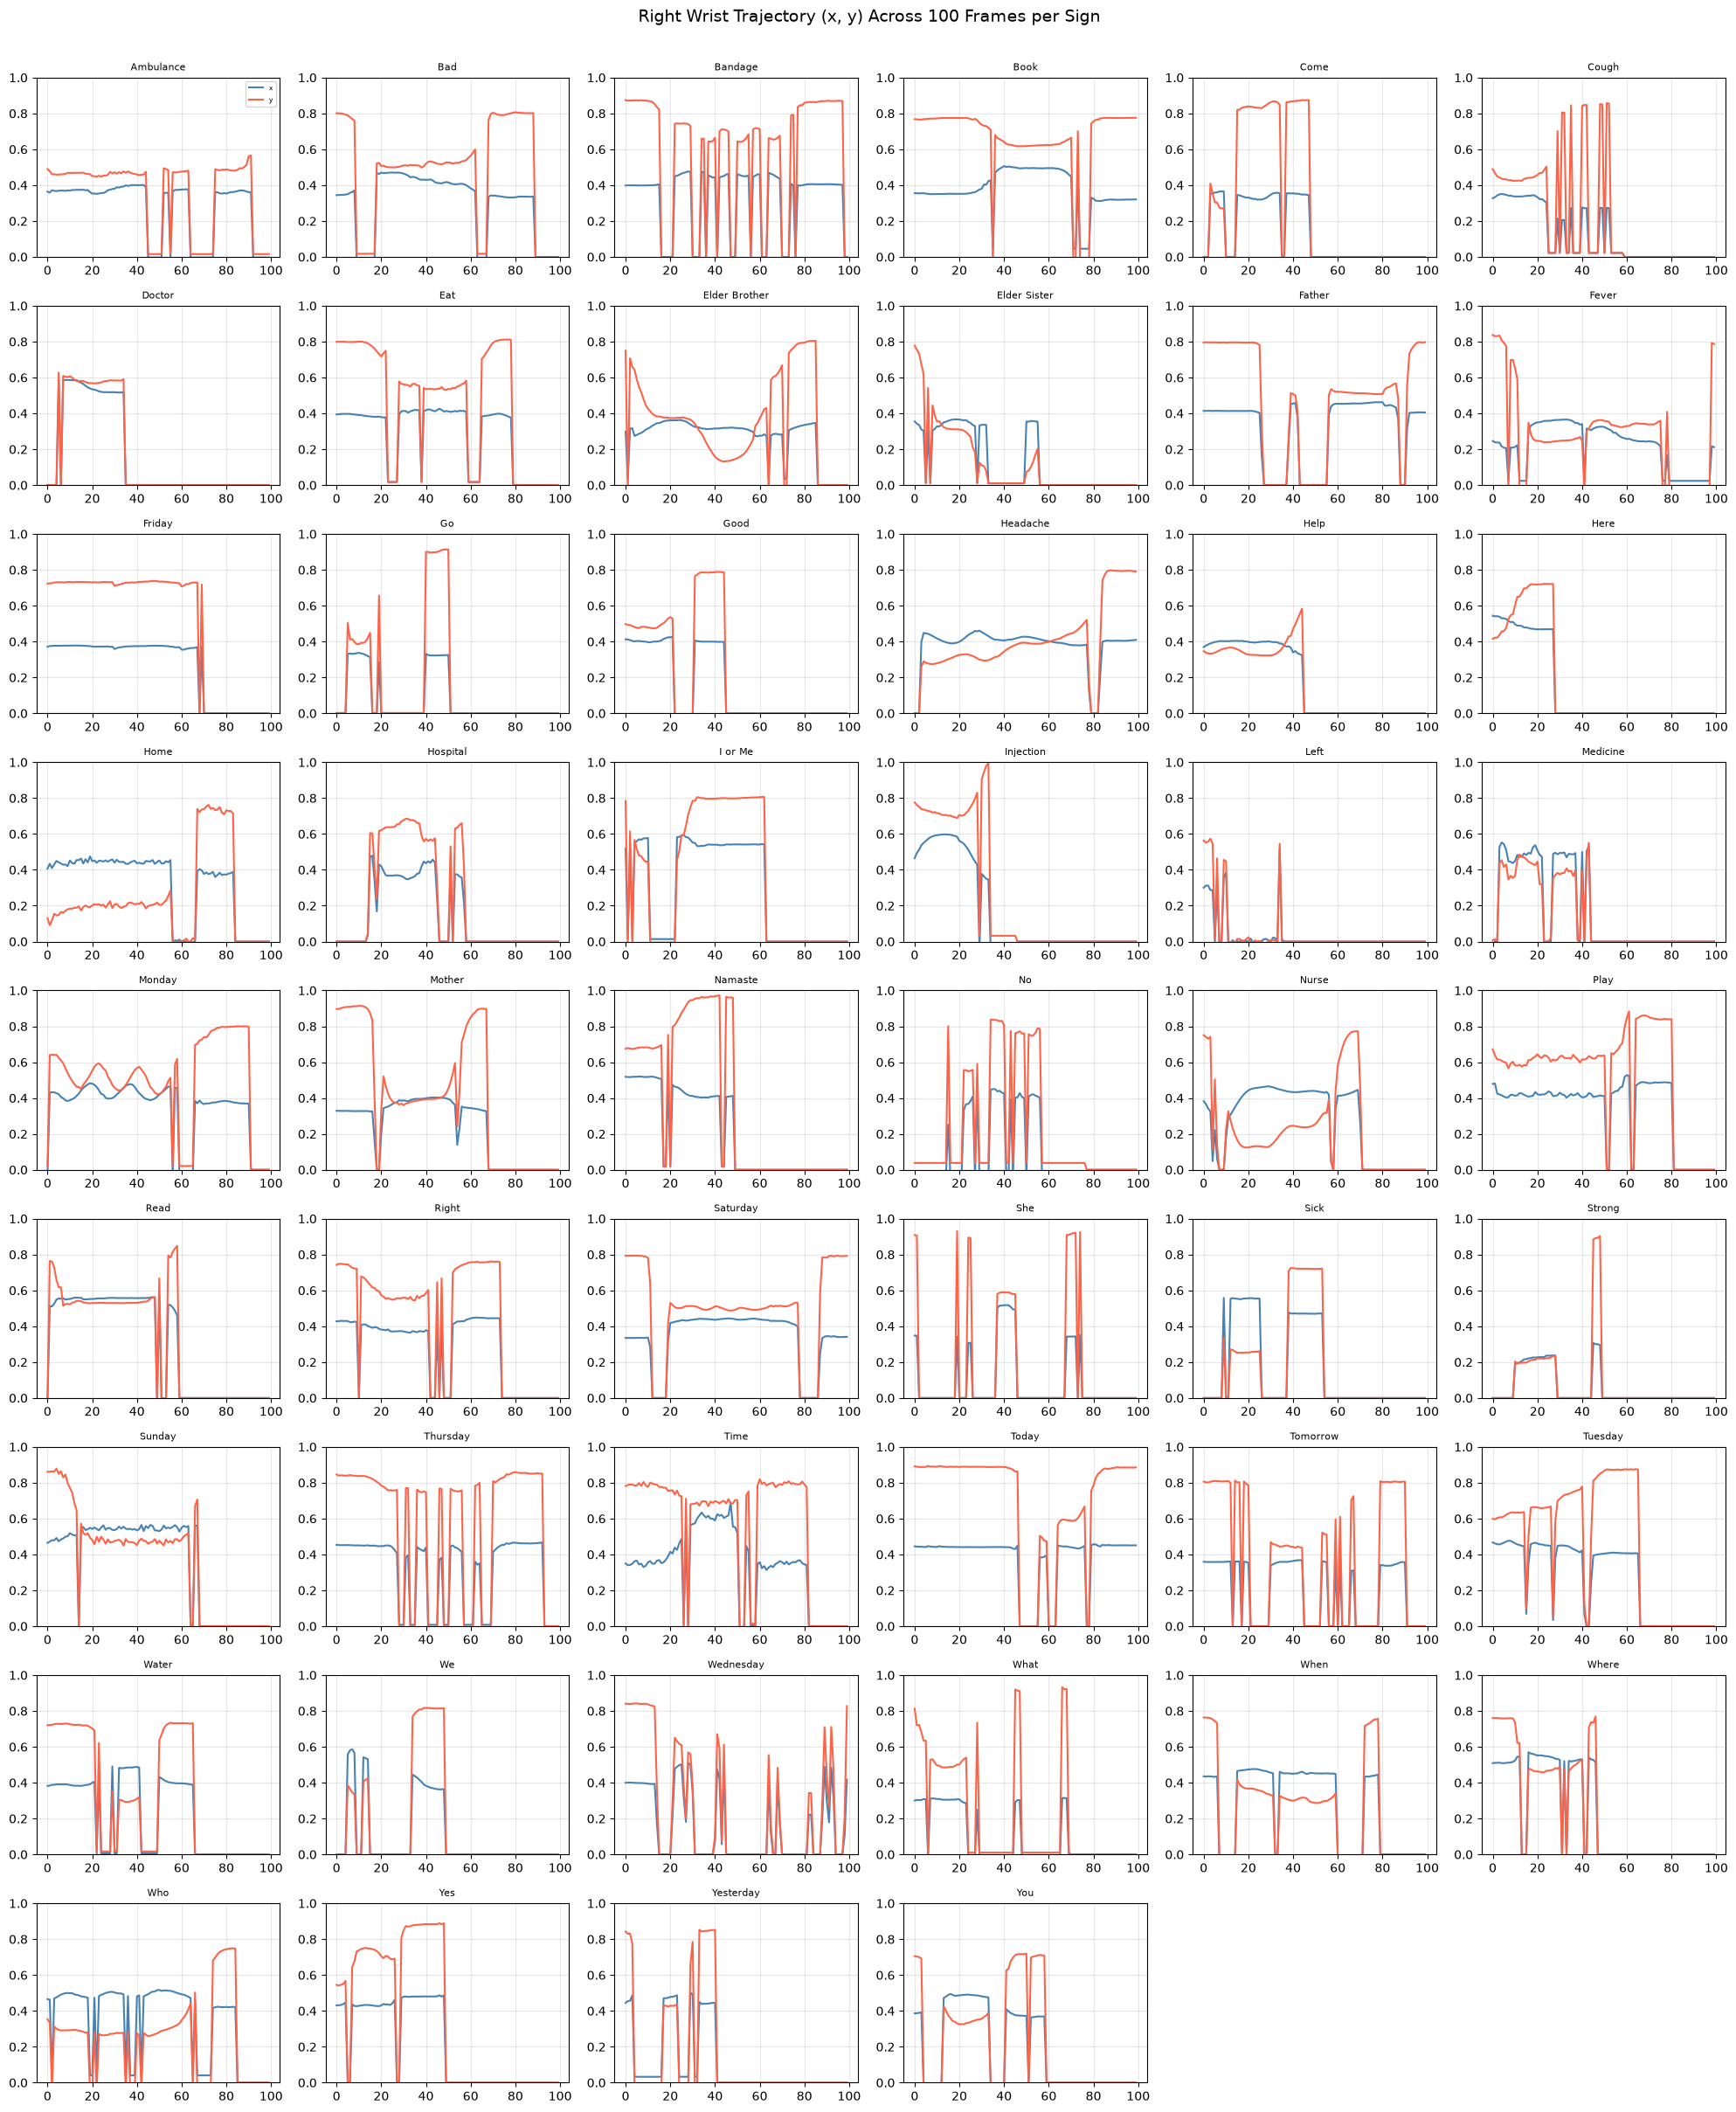

✅ Wrist trajectory saved


In [9]:
fig, axes = plt.subplots(9, 6, figsize=(20, 24))
axes = axes.flatten()

RIGHT_WRIST_X = 228
RIGHT_WRIST_Y = 229

for i, sign in enumerate(SIGNS):
    mask_i = test_true == i
    if mask_i.sum() == 0:
        continue

    sample = X_test[mask_i][0]   # shape (100, 291)

    right_wrist_x = sample[:, RIGHT_WRIST_X]
    right_wrist_y = sample[:, RIGHT_WRIST_Y]

    frames = list(range(FIXED_LEN))
    axes[i].plot(frames, right_wrist_x, label='x', color='steelblue', linewidth=1.5)
    axes[i].plot(frames, right_wrist_y, label='y', color='tomato',    linewidth=1.5)
    axes[i].set_title(sign, fontsize=8)
    axes[i].set_ylim(0, 1)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(fontsize=6)

for j in range(len(SIGNS), len(axes)):
    axes[j].axis('off')

fig.suptitle('Right Wrist Trajectory (x, y) Across 100 Frames per Sign', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig("figures/wrist_trajectory.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Wrist trajectory saved")

In [12]:
POSE_SLICE  = slice(0, 165)
LHAND_SLICE = slice(165, 228)
RHAND_SLICE = slice(228, 291)

detection_stats = {}
total_frames = 0
total_pose   = 0
total_lhand  = 0
total_rhand  = 0
total_either = 0

for i, sign in enumerate(SIGNS):
    mask_i = (test_true == i)
    if mask_i.sum() == 0:
        continue

    sign_samples = X_test[mask_i]          # (n_samples, 100, 291)
    sign_lengths = lengths_test[mask_i]    # actual (unpadded) length per sample

    sign_total, sign_pose, sign_lhand, sign_rhand, sign_missing = 0, 0, 0, 0, 0

    for sample, length in zip(sign_samples, sign_lengths):
        real_frames = sample[:length]      # ignore padded frames

        for frame in real_frames:
            sign_total += 1
            pose_present  = not np.allclose(frame[POSE_SLICE], 0)
            left_present  = not np.allclose(frame[LHAND_SLICE], 0)
            right_present = not np.allclose(frame[RHAND_SLICE], 0)

            if pose_present:
                sign_pose += 1
            if left_present:
                sign_lhand += 1
            if right_present:
                sign_rhand += 1
            if not left_present and not right_present:
                sign_missing += 1

    detection_stats[sign] = {
        'total': sign_total, 'pose': sign_pose,
        'lhand': sign_lhand, 'rhand': sign_rhand, 'missing': sign_missing
    }
    total_frames += sign_total
    total_pose   += sign_pose
    total_lhand  += sign_lhand
    total_rhand  += sign_rhand
    total_either += (sign_total - sign_missing)

    if sign_total > 0:
        print(f"{sign:15s}: total={sign_total} "
              f"pose={sign_pose/sign_total*100:.0f}% "
              f"lhand={sign_lhand/sign_total*100:.0f}% "
              f"rhand={sign_rhand/sign_total*100:.0f}% "
              f"missing={sign_missing/sign_total*100:.0f}%")

print(f"\n{'='*60}")
print(f"TOTAL FRAMES:      {total_frames}")
print(f"Pose detected:     {total_pose} ({total_pose/total_frames*100:.1f}%)")
print(f"Left hand:         {total_lhand} ({total_lhand/total_frames*100:.1f}%)")
print(f"Right hand:        {total_rhand} ({total_rhand/total_frames*100:.1f}%)")
print(f"At least one hand: {total_either} ({total_either/total_frames*100:.1f}%)")

Ambulance      : total=4135 pose=100% lhand=94% rhand=91% missing=2%
Bad            : total=3297 pose=100% lhand=96% rhand=91% missing=0%
Bandage        : total=3482 pose=100% lhand=89% rhand=85% missing=6%
Book           : total=2634 pose=100% lhand=88% rhand=88% missing=7%
Come           : total=2353 pose=99% lhand=85% rhand=83% missing=6%
Cough          : total=2591 pose=100% lhand=87% rhand=86% missing=6%
Doctor         : total=2637 pose=100% lhand=87% rhand=81% missing=6%
Eat            : total=2465 pose=100% lhand=80% rhand=78% missing=11%
Elder Brother  : total=2889 pose=100% lhand=91% rhand=86% missing=3%
Elder Sister   : total=3000 pose=100% lhand=86% rhand=80% missing=8%
Father         : total=2783 pose=100% lhand=80% rhand=87% missing=4%
Fever          : total=3618 pose=100% lhand=99% rhand=90% missing=0%
Friday         : total=2710 pose=100% lhand=83% rhand=92% missing=3%
Go             : total=2494 pose=100% lhand=94% rhand=83% missing=3%
Good           : total=2513 pose=1

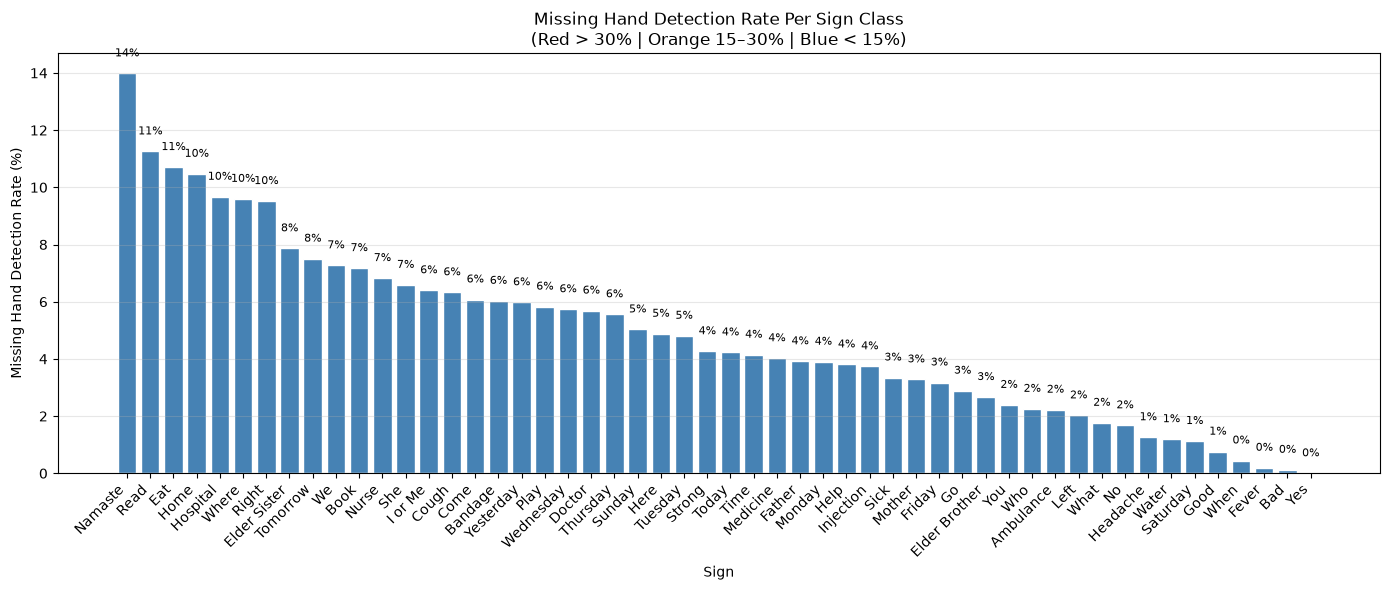

✅ Detection rate chart saved


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

signs_list   = list(detection_stats.keys())
missing_rates = [
    detection_stats[s]['missing'] / detection_stats[s]['total'] * 100
    for s in signs_list
]

sorted_pairs  = sorted(zip(missing_rates, signs_list), reverse=True)
sorted_rates  = [x[0] for x in sorted_pairs]
sorted_signs2 = [x[1] for x in sorted_pairs]

colors = ['tomato' if r > 30 else 'orange' if r > 15 else 'steelblue'
          for r in sorted_rates]

bars = ax.bar(sorted_signs2, sorted_rates, color=colors, edgecolor='white')
ax.set_xlabel('Sign')
ax.set_ylabel('Missing Hand Detection Rate (%)')
ax.set_title('Missing Hand Detection Rate Per Sign Class\n(Red > 30% | Orange 15–30% | Blue < 15%)')
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for bar, rate in zip(bars, sorted_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{rate:.0f}%',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("figures/detection_rate.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Detection rate chart saved")

In [15]:
model.eval()

# Warm up GPU
dummy_x = torch.randn(1, FIXED_LEN, FEAT_DIM).to(DEVICE)
dummy_len = torch.LongTensor([FIXED_LEN]).to(DEVICE)
for _ in range(10):
    with torch.no_grad():
        _ = model(dummy_x, dummy_len)

N_RUNS = 100
times = []

for _ in range(N_RUNS):
    x = torch.randn(1, FIXED_LEN, FEAT_DIM).to(DEVICE)
    length = torch.LongTensor([FIXED_LEN]).to(DEVICE)
    start = time.perf_counter()
    with torch.no_grad():
        _ = model(x, length)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    end = time.perf_counter()
    times.append((end - start) * 1000)

avg_latency = np.mean(times)
std_latency = np.std(times)

print(f"Inference Latency (per sample):")
print(f"  Mean: {avg_latency:.2f} ms")
print(f"  Std:  {std_latency:.2f} ms")
print(f"  Min:  {np.min(times):.2f} ms")
print(f"  Max:  {np.max(times):.2f} ms")
print(f"  Throughput: {1000/avg_latency:.0f} samples/sec")

Inference Latency (per sample):
  Mean: 5.99 ms
  Std:  4.77 ms
  Min:  2.43 ms
  Max:  21.42 ms
  Throughput: 167 samples/sec


In [16]:
print("\n" + "="*60)
print("COMPLETE RESULTS SUMMARY")
print("="*60)
print(f"\n── Transformer Classifier ──")
print(f"Test Accuracy:      {accuracy*100:.2f}%")
print(f"Top-3 Accuracy:     {top3_acc*100:.2f}%")
print(f"Cohen's Kappa:      {kappa:.4f}")
print(f"Macro F1:           {report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1:        {report['weighted avg']['f1-score']:.4f}")
print(f"Parameters:         {total_params:,}")
print(f"Model Size:         {model_size:.2f} MB")
print(f"Inference Latency:  {avg_latency:.2f} ± {std_latency:.2f} ms")

print(f"\n── Landmark Detection (test set) ──")
print(f"Total Frames:       {total_frames}")
print(f"Pose Detection:     {total_pose/total_frames*100:.1f}%")
print(f"Left Hand:          {total_lhand/total_frames*100:.1f}%")
print(f"Right Hand:         {total_rhand/total_frames*100:.1f}%")
print(f"At Least One Hand:  {total_either/total_frames*100:.1f}%")

print(f"\n── Figures Saved ──")
for f in os.listdir("figures"):
    size = os.path.getsize(f"figures/{f}") / 1024
    print(f"  {f:35s} {size:.0f} KB")

print("\n✅ All done! Copy figures/ to your LaTeX src/images/figures/ folder")


COMPLETE RESULTS SUMMARY

── Transformer Classifier ──
Test Accuracy:      76.06%
Top-3 Accuracy:     93.16%
Cohen's Kappa:      0.7559
Macro F1:           0.7559
Weighted F1:        0.7563
Parameters:         804,468
Model Size:         3.16 MB
Inference Latency:  5.99 ± 4.77 ms

── Landmark Detection (test set) ──
Total Frames:       148084
Pose Detection:     99.8%
Left Hand:          88.6%
Right Hand:         85.8%
At Least One Hand:  95.3%

── Figures Saved ──
  acc_curve.png                       85 KB
  confusion_matrix.png                612 KB
  detection_rate.png                  129 KB
  f1_barchart.png                     225 KB
  loss_curve.png                      70 KB
  tsne.png                            557 KB
  wrist_trajectory.png                1089 KB

✅ All done! Copy figures/ to your LaTeX src/images/figures/ folder
